In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import seaborn as sns
import bioframe as bf
import cooler
import cooltools
import warnings

In [23]:
colors = {
    "Neuron": "#E07A7A",
    "Glia": "#D08AD0", 
    "GSC": "#4D7F7F"
}

In [3]:
clr_path = {
    "GSC": "data/G1.mcool",
   "Glia": "glia.mcool", 
   "Neuron": "hc_plus_merged.sampled.drop_diag.1kb.mcool"
}

cts = list(clr_path.keys()) 

In [4]:
res = 10000
clrs = {ct:
    cooler.Cooler(clr_path[ct] + f'::resolutions/{res}') 
    for ct in cts}

clrs

{'GSC': <Cooler "G1.mcool::/resolutions/10000">,
 'Glia': <Cooler "glia.mcool::/resolutions/10000">,
 'Neuron': <Cooler "hc_plus_merged.sampled.drop_diag.1kb.mcool::/resolutions/10000">}

In [5]:
cvd_smooth_agg = {}

for ct, clr in clrs.items():
    print(ct)
    cvd_smooth_agg[ct] = cooltools.expected_cis(
        clr=clrs[ct],
        smooth=True,
        aggregate_smoothed=True,
        nproc=16
    )

INFO:root:creating a Pool of 16 workers


GSC


/home/iuliia_parshchikova/miniconda3/envs/hic_pipeline/lib/python3.10/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))
INFO:root:creating a Pool of 16 workers


Glia


/home/iuliia_parshchikova/miniconda3/envs/hic_pipeline/lib/python3.10/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))
INFO:root:creating a Pool of 16 workers


Neuron


/home/iuliia_parshchikova/miniconda3/envs/hic_pipeline/lib/python3.10/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))


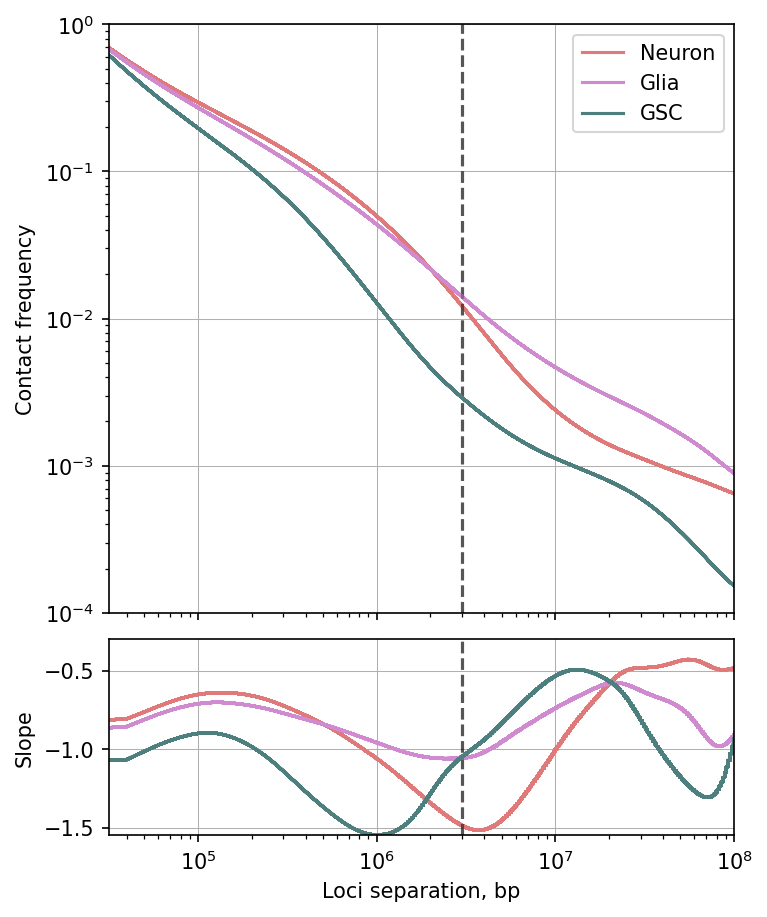

In [31]:
# Plot expected
warnings.filterwarnings('ignore')
f, axs = plt.subplots(2, 1, dpi=150, sharex=True, gridspec_kw={'height_ratios':[3, 1]}, 
                      figsize=(5, 6), 
                      layout="constrained")

i=0
for ct, clr in clrs.items():
    # Add distance value and drop first two columns
    cvd_smooth_agg[ct].loc[:, 's_bp'] = cvd_smooth_agg[ct]['dist'] * res
    cvd_smooth_agg[ct].loc[cvd_smooth_agg[ct]['dist'] < 2, 
                           'balanced.avg.smoothed.agg'] = np.nan
    
    # Normalize so that all lines start at 1
    cvd_smooth_agg[ct].loc[:, 'balanced.avg.smoothed.agg.norm'] = \
        cvd_smooth_agg[ct]['balanced.avg.smoothed.agg'] / \
        cvd_smooth_agg[ct]['balanced.avg.smoothed.agg'].values[2]

    # Calculate slope
    der = np.gradient(np.log(cvd_smooth_agg[ct]['balanced.avg.smoothed.agg.norm']),
                      np.log(cvd_smooth_agg[ct]['s_bp']))

    # Plot scaling
    ax = axs[0]
    ax.plot([3e6, 3e6], [1e-4, 1], 'k--', alpha=0.3)
    ax.loglog(
        cvd_smooth_agg[ct]['s_bp'],
        cvd_smooth_agg[ct]['balanced.avg.smoothed.agg.norm'],
        label=f"{ct}",
        color=colors[ct],
    )

    ax.set(ylabel='Contact frequency')
    ax.set_xlim([31600, 1e8])
    ax.set_ylim([1e-4, 1])
    # ax.set_adjustable("box")
    # ax.set_aspect(1)
    ax.grid(lw=0.5)
    ax.legend()

    # Plot slope
    ax = axs[1]
    ax.plot([3e6, 3e6], [-1.55, -0.3], 'k--', alpha=0.3)
    ax.semilogx(
        cvd_smooth_agg[ct]['s_bp'],
        der,
        color=colors[ct],
    )

    ax.set(
        xlabel='Loci separation, bp',
        ylabel='Slope',
    )

    ax.grid(lw=0.5)
    ax.set_xlim([31600, 1e8])
    ax.set_xticks([1e5, 1e6, 1e7, 1e8], minor=False)
    ax.set_ylim([-1.55, -0.3])